Import used libraries

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import iirfilter, filtfilt
print ('Done!')

Done!


Init some functions that we need

In [2]:
# harmonic_with_noise (task 1 and 8)
def harmonic_with_noise(t, amplitude, frequency, phase, noise_mean, noise_covariance, show_noise):
    global current_noise, prev_noise_params
    pure = amplitude * np.sin(2 * np.pi * frequency * t + phase) # pure harmonic
    if prev_noise_params != (noise_mean, noise_covariance): # If noise params had not changed we don`t generate it again (tsk 5)
        current_noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), len(t))
        prev_noise_params = (noise_mean, noise_covariance)
        
    noisy = pure + current_noise if show_noise else pure # noise depends on the "show noise" param enabled or not
    return pure, noisy

In [3]:
def apply_filter(data, cutoff=10, fs=1000, order=5):
    # use of butterworth filter (task 7)
    b, a = iirfilter(N=order, Wn=cutoff, btype='lowpass', analog=False, ftype='butter', fs=fs)
    return filtfilt(b, a, data)

In [4]:
def update(val):
    # func to update our shown data based on changes in UI sliders (task 3 and 5)
    # checkbox states (task 4)
    show_noise = check.get_status()[0]
    show_filt = check.get_status()[1]
    # updated signal data
    pure, noisy = harmonic_with_noise(t, s_amp.val, s_freq.val, s_phase.val, s_n_mean.val, s_n_cov.val, show_noise)
    # updated visual lines
    line_pure.set_ydata(pure)
    line_noisy.set_ydata(noisy)
    
    if show_filt:
        filtered = apply_filter(noisy, cutoff=s_f_cut.val)
        line_filt.set_ydata(filtered)
        line_filt.set_visible(True)
    else:
        line_filt.set_visible(False)
    # trigger upddate in canvas (update the graph)
    fig.canvas.draw_idle()

In [5]:
def reset(event):
    # resets all sliders to their init values (task 6)
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_n_mean.reset()
    s_n_cov.reset()
    s_f_cut.reset()

In [6]:
# Start params / init values (task 3)
init_amp = 1.0
init_freq = 2.0
init_phase = 0.0
init_noise_mean = 0.0
init_noise_cov = 0.1
t = np.linspace(0, 1, 1000)

# Global variables to save noise state (task 5)
current_noise = np.random.normal(init_noise_mean, np.sqrt(init_noise_cov), len(t))
prev_noise_params = (init_noise_mean, init_noise_cov)

Now we can create our plot!

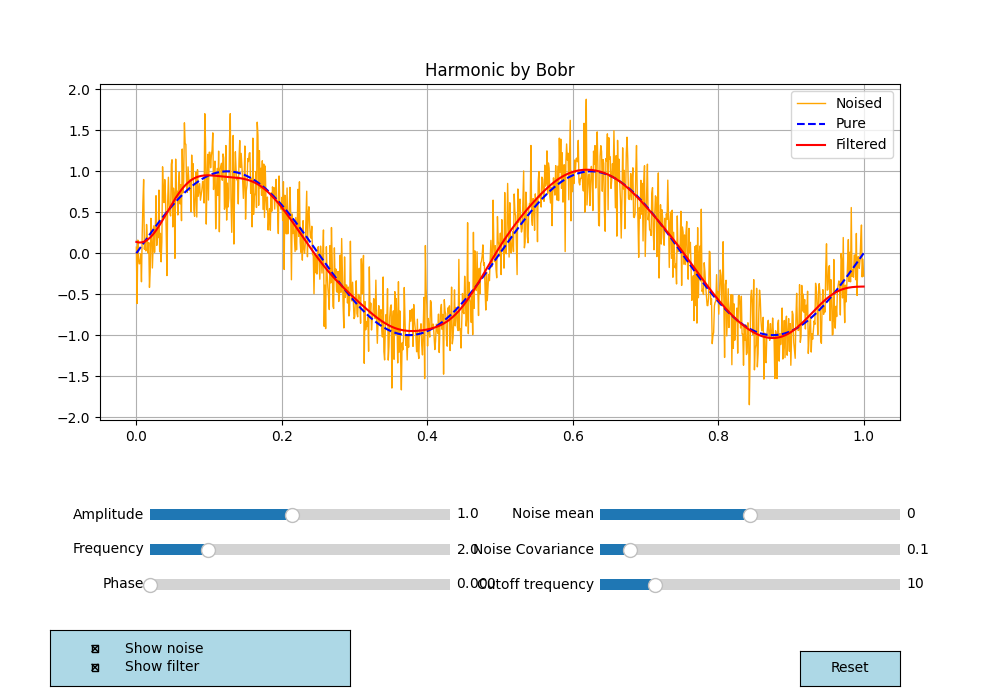

In [7]:
# (task 2, 9 and 10)
fig, ax = plt.subplots(figsize=(10, 7)) # size of our plot
plt.subplots_adjust(left=0.1, bottom=0.4) # some space for sliders

# generate data for first render
pure_sig, noisy_sig = harmonic_with_noise(t, init_amp, init_freq, init_phase, init_noise_mean, init_noise_cov, True)
filtered_sig = apply_filter(noisy_sig)

# lines of our graph
line_noisy, = ax.plot(t, noisy_sig, label='Noised', color='orange', lw=1)
line_pure, = ax.plot(t, pure_sig, label='Pure', color='blue', linestyle='--')
line_filt, = ax.plot(t, filtered_sig, label='Filtered', color='red', lw=1.5)

# some misc settings
ax.set_title("Harmonic by Bobr")
ax.legend(loc='upper right')
ax.grid(True)
ax_color = 'lightblue'

# Sliders for harmonic
ax_amp = plt.axes([0.15, 0.25, 0.3, 0.03], facecolor=ax_color)
ax_freq = plt.axes([0.15, 0.20, 0.3, 0.03], facecolor=ax_color)
ax_phase = plt.axes([0.15, 0.15, 0.3, 0.03], facecolor=ax_color)
s_amp = Slider(ax_amp, 'Amplitude', 0.1, 2.0, valinit=init_amp)
s_freq = Slider(ax_freq, 'Frequency', 0.1, 10.0, valinit=init_freq)
s_phase = Slider(ax_phase, 'Phase', 0.0, 2*np.pi, valinit=init_phase)

# sliders for noise and filter
ax_n_mean = plt.axes([0.6, 0.25, 0.3, 0.03], facecolor=ax_color)
ax_n_cov = plt.axes([0.6, 0.20, 0.3, 0.03], facecolor=ax_color)
ax_f_cut = plt.axes([0.6, 0.15, 0.3, 0.03], facecolor=ax_color)
s_n_mean = Slider(ax_n_mean, 'Noise mean', -1.0, 1.0, valinit=init_noise_mean)
s_n_cov = Slider(ax_n_cov, 'Noise Covariance', 0.0, 1.0, valinit=init_noise_cov)
s_f_cut = Slider(ax_f_cut, 'Cutoff trequency', 1, 50, valinit=10)

# Checkboxes for noise and filter
ax_check = plt.axes([0.05, 0.02, 0.3, 0.08], facecolor=ax_color)
check = CheckButtons(ax_check, ('Show noise', 'Show filter'), (True, True))

# Reset button
ax_reset = plt.axes([0.8, 0.02, 0.1, 0.05])
button_reset = Button(ax_reset, 'Reset', color=ax_color, hovercolor='0.975')

# update triggers
s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_n_mean.on_changed(update)
s_n_cov.on_changed(update)
s_f_cut.on_changed(update)
check.on_clicked(update)

# trigger on reset button
button_reset.on_clicked(reset)

# show our fantastic super-duper cool plot
plt.show()